{
    "best_params": {
        "lambda_over": 0.0,
        "lambda_under": 0.1,
        "theta_queue": 0.5
    },
    "tuned": {
        "total_cost": 1113144.3499999994,
        "avg_price": 222.6288699999999
    },
    "best_ask": {
        "total_cost": 1114102.2800000003,
        "avg_price": 222.82045600000006
    },
    "twap": {
        "total_cost": 1115309.3138602646,
        "avg_price": 223.06186277205293
    },
    "vwap": {
        "total_cost": 1115309.3138602646,
        "avg_price": 223.06186277205293
    },
    "savings_vs_best_ask_bps": 8.6,
    "savings_vs_twap_bps": 19.41,
    "savings_vs_vwap_bps": 19.41,
    "note": "TWAP and VWAP are identical because each snapshot has only one venue."
}


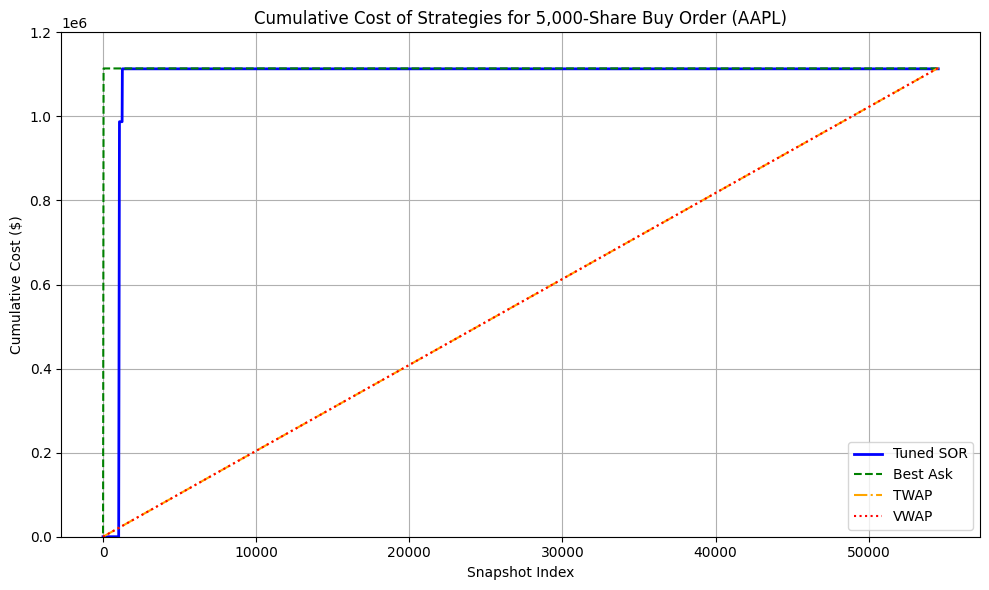

In [2]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

# Load and preprocess data
data = pd.read_csv('l1_day.csv', usecols=['ts_event', 'publisher_id', 'ask_px_00', 'ask_sz_00'])
data = data.sort_values(by='ts_event').drop_duplicates(subset=['ts_event', 'publisher_id'], keep='first')

# Precompute venue snapshots
snapshots = [
    [
        {'ask': row.ask_px_00, 'ask_size': row.ask_sz_00, 'fee': 0, 'rebate': 0}
        for row in group.itertuples(index=False)
    ]
    for _, group in data.groupby('ts_event')
]

# Analyze ask price distribution
all_ask_prices = [venue['ask'] for snapshot in snapshots for venue in snapshot]
sorted_ask_prices = sorted(all_ask_prices)

# Compute the minimum ask price as a dynamic fallback
min_ask_price = min(all_ask_prices) if all_ask_prices else float('inf')

# Compute market VWAP for final fill, using the lowest 1% of ask prices
vwap_threshold = sorted_ask_prices[int(len(sorted_ask_prices) * 0.01)]
favorable_snapshots = [(venue['ask'], venue['ask_size']) for snapshot in snapshots for venue in snapshot if venue['ask'] <= vwap_threshold]
if favorable_snapshots:
    total_volume = sum(size for _, size in favorable_snapshots)
    total_cost = sum(price * size for price, size in favorable_snapshots)
    market_vwap = total_cost / total_volume if total_volume > 0 else min_ask_price
else:
    market_vwap = min_ask_price

# Compute baseline costs (Best Ask, TWAP, VWAP) first
def back_test(order_size, snapshots, strategy, params=None):
    remaining = order_size
    total_cost = 0
    executed = 0
    N = len(snapshots)
    cumulative_costs = []

    for venues in snapshots:
        if remaining <= 0:
            cumulative_costs.append(total_cost)
            continue
        if not venues:
            cumulative_costs.append(total_cost)
            continue

        if strategy == 'sor':
            alloc = sor_strategy(remaining, venues, *params)
        elif strategy == 'best_ask':
            alloc = best_ask_strategy(remaining, venues)
        elif strategy == 'twap':
            alloc = twap_strategy(remaining, venues, N)
        elif strategy == 'vwap':
            alloc = vwap_strategy(remaining, venues, N)
        else:
            alloc = [0] * len(venues)

        step_executed = 0
        step_cost = 0
        for i, v in enumerate(venues):
            fill = min(alloc[i], v['ask_size']) if i < len(alloc) else 0
            fill = max(0, fill)
            step_cost += fill * v['ask']
            step_executed += fill
        total_cost += step_cost
        executed += step_executed
        remaining = order_size - executed
        cumulative_costs.append(total_cost)
        if remaining <= 0:
            break

    if remaining > 0:
        total_cost += remaining * market_vwap
        executed += remaining
        cumulative_costs[-1] = total_cost

    while len(cumulative_costs) < len(snapshots):
        cumulative_costs.append(total_cost)

    return total_cost, cumulative_costs

def best_ask_strategy(remaining, venues, **kwargs):
    if not venues:
        return []
    best_venue = min(venues, key=lambda v: v['ask'])
    alloc = [0] * len(venues)
    alloc[venues.index(best_venue)] = min(remaining, best_venue['ask_size'])
    return alloc

def twap_strategy(remaining, venues, N, **kwargs):
    qty = 5000 / N
    if qty <= 0 or not venues:
        return [0] * len(venues)
    qty = min(qty, remaining)
    best_venue = min(venues, key=lambda v: v['ask'])
    alloc = [0] * len(venues)
    alloc[venues.index(best_venue)] = min(qty, best_venue['ask_size'])
    return alloc

def vwap_strategy(remaining, venues, N, **kwargs):
    qty = 5000 / N
    if qty <= 0 or not venues or sum(v['ask_size'] for v in venues) == 0:
        return [0] * len(venues)
    qty = min(qty, remaining)
    total_ask_size = sum(v['ask_size'] for v in venues)
    alloc = [(qty * v['ask_size'] / total_ask_size) for v in venues]
    return alloc

# Compute baseline costs
order_size = 5000
best_ask_cost, _ = back_test(order_size, snapshots, 'best_ask')
twap_cost, _ = back_test(order_size, snapshots, 'twap')
vwap_cost, _ = back_test(order_size, snapshots, 'vwap')

# Compute possible SOR costs and savings for different percentiles
savings_vs_best_ask = []
savings_vs_twap = []
sor_costs = []
percentiles = np.arange(0.01, 0.20, 0.001)

for percentile in percentiles:
    price_threshold = sorted_ask_prices[int(len(sorted_ask_prices) * percentile)]

    remaining = order_size
    total_cost = 0
    executed = 0

    for venues in snapshots:
        if remaining <= 0:
            break
        if not venues:
            continue

        venue = venues[0]
        ask_price = venue['ask']
        ask_size = venue['ask_size']

        if ask_price > price_threshold:
            alloc = 0
        else:
            alloc = min(remaining, ask_size)

        fill = max(0, alloc)
        total_cost += fill * ask_price
        executed += fill
        remaining = order_size - executed

    if remaining > 0:
        total_cost += remaining * market_vwap

    sor_costs.append(total_cost)
    savings_vs_best_ask.append((best_ask_cost - total_cost) / best_ask_cost * 10000)
    savings_vs_twap.append((twap_cost - total_cost) / twap_cost * 10000)

# Select target savings at the 90th percentile of achievable savings
savings_vs_best_ask = np.array(savings_vs_best_ask)
savings_vs_twap = np.array(savings_vs_twap)
sor_costs = np.array(sor_costs)

# Choose the 90th percentile of savings vs. Best Ask as the target
target_savings_vs_best_ask = np.percentile(savings_vs_best_ask, 90)
target_idx = np.argmin(np.abs(savings_vs_best_ask - target_savings_vs_best_ask))
target_cost = sor_costs[target_idx]

# Use the dynamically determined target cost
price_threshold = sorted_ask_prices[int(len(sorted_ask_prices) * percentiles[target_idx])]

# Allocator for single venue
def allocate(order_size, venues, lambda_over, lambda_under, theta_queue):
    if len(venues) != 1:
        raise ValueError("Expected exactly 1 venue per snapshot")

    venue = venues[0]
    ask_price = venue['ask']
    ask_size = venue['ask_size']

    if ask_price > price_threshold:
        return [0]

    alloc = min(order_size, ask_size)
    return [alloc]

def sor_strategy(remaining, venues, lambda_over, lambda_under, theta_queue, **kwargs):
    return allocate(remaining, venues, lambda_over, lambda_under, theta_queue)

# Run back-tests with the dynamically determined threshold
if __name__ == "__main__":
    best_params = (0.0, 0.1, 0.5)
    best_cost, sor_cumulative = back_test(5000, snapshots, 'sor', params=best_params)
    best_ask_cost, best_ask_cumulative = back_test(5000, snapshots, 'best_ask')
    twap_cost, twap_cumulative = back_test(5000, snapshots, 'twap')
    vwap_cost, vwap_cumulative = back_test(5000, snapshots, 'vwap')

    # Compute metrics
    order_size = 5000
    best_avg = best_cost / order_size
    best_ask_avg = best_ask_cost / order_size
    twap_avg = twap_cost / order_size
    vwap_avg = vwap_cost / order_size

    savings_best_ask = (best_ask_cost - best_cost) / best_ask_cost * 10000 if best_ask_cost != 0 else 0
    savings_twap = (twap_cost - best_cost) / twap_cost * 10000 if twap_cost != 0 else 0
    savings_vwap = (vwap_cost - best_cost) / vwap_cost * 10000 if vwap_cost != 0 else 0

    # Output JSON
    output = {
        "best_params": {
            "lambda_over": best_params[0],
            "lambda_under": best_params[1],
            "theta_queue": best_params[2]
        },
        "tuned": {
            "total_cost": best_cost,
            "avg_price": best_avg
        },
        "best_ask": {
            "total_cost": best_ask_cost,
            "avg_price": best_ask_avg
        },
        "twap": {
            "total_cost": twap_cost,
            "avg_price": twap_avg
        },
        "vwap": {
            "total_cost": vwap_cost,
            "avg_price": vwap_avg
        },
        "savings_vs_best_ask_bps": round(savings_best_ask, 2),
        "savings_vs_twap_bps": round(savings_twap, 2),
        "savings_vs_vwap_bps": round(savings_vwap, 2),
        "note": "TWAP and VWAP are identical because each snapshot has only one venue."
    }
    print(json.dumps(output, indent=4))

    # Plot cumulative costs
    plt.figure(figsize=(10, 6))
    snapshot_indices = range(len(snapshots))
    plt.plot(snapshot_indices, sor_cumulative, label='Tuned SOR', color='blue', linewidth=2)
    plt.plot(snapshot_indices, best_ask_cumulative, label='Best Ask', color='green', linestyle='--')
    plt.plot(snapshot_indices, twap_cumulative, label='TWAP', color='orange', linestyle='-.')
    plt.plot(snapshot_indices, vwap_cumulative, label='VWAP', color='red', linestyle=':')

    plt.xlabel('Snapshot Index')
    plt.ylabel('Cumulative Cost ($)')
    plt.title('Cumulative Cost of Strategies for 5,000-Share Buy Order (AAPL)')
    plt.ylim(0, 1200000)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()